In [1]:
# including packages
using LazyGrids, PyPlot, BenchmarkTools
using PSFModels, ImageFiltering
using PyPlot
include("LensBase.jl")
include("LensUtils.jl")
include("LensFITS.jl")
include("LensGenerator.jl")

Main.LensGenerator

In [2]:
module_names = LensUtils.include_folder("LightModels//");
include.(module_names)

4-element Vector{Union{Nothing, Module}}:
 Main.ExponentialLight
 Main.GaussianLight
 nothing
 Main.SersicLight

In [3]:
x = range(-2, 2, 51)
xg, yg = LazyGrids.ndgrid(x,x)

([-2.0 -2.0 … -2.0 -2.0; -1.92 -1.92 … -1.92 -1.92; … ; 1.92 1.92 … 1.92 1.92; 2.0 2.0 … 2.0 2.0], [-2.0 -1.92 … 1.92 2.0; -2.0 -1.92 … 1.92 2.0; … ; -2.0 -1.92 … 1.92 2.0; -2.0 -1.92 … 1.92 2.0])

# Gaussian

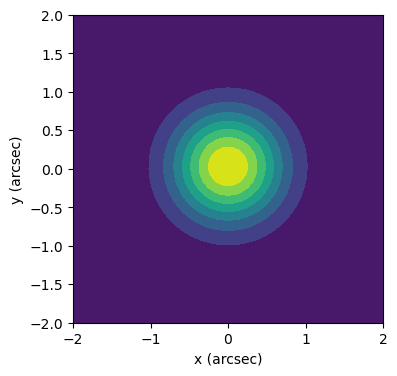

PyObject Text(23.999999999999993, 0.5, 'y (arcsec)')

In [4]:
# Light Parameters
LightParaDict = Dict(:amp=>1., :sigma=>0.5,
                :xcentre=>0.03, :ycentre=>0.0)
# Gaussian Light Profile
SourceLight = GaussianLight.GaussianSphere(xg, yg; LightParaDict...);
fig, ax = PyPlot.subplots(figsize=(4,4))
ax.contourf(x, x, SourceLight)
ax.set_xlabel("x (arcsec)")
ax.set_ylabel("y (arcsec)")

# Elliptical Gaussian

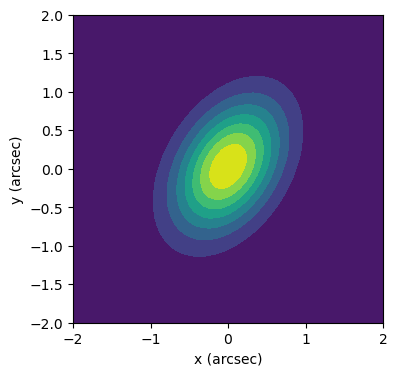

PyObject Text(23.999999999999993, 0.5, 'y (arcsec)')

In [5]:
# Light Parameters
LightParaDict = Dict(:amp=>1., :sigma=>0.5, :e1=>0.1, :e2=>0.2,
                :xcentre=>0.03, :ycentre=>0.0)

SourceLight = GaussianLight.GaussianEllipse(xg, yg; LightParaDict...);
fig, ax = PyPlot.subplots(figsize=(4,4))
ax.contourf(x, x, SourceLight)
ax.set_xlabel("x (arcsec)")
ax.set_ylabel("y (arcsec)")

# Exponential spherical

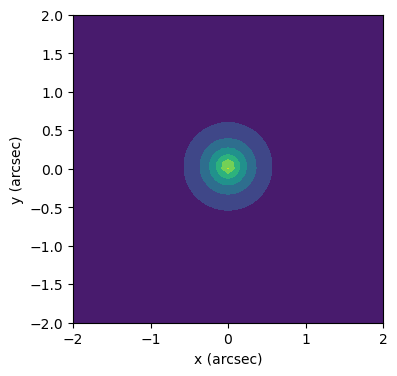

PyObject Text(23.999999999999993, 0.5, 'y (arcsec)')

In [6]:
# Light Parameters
LightParaDict = Dict(:amp=>1., :Rsersic=>0.5,
                :xcentre=>0.03, :ycentre=>0.0)

SourceLight = ExponentialLight.ExponentialSpheric(xg, yg; LightParaDict...);
fig, ax = PyPlot.subplots(figsize=(4,4))
ax.contourf(x, x, SourceLight)
ax.set_xlabel("x (arcsec)")
ax.set_ylabel("y (arcsec)")

# Exponential Elliptical

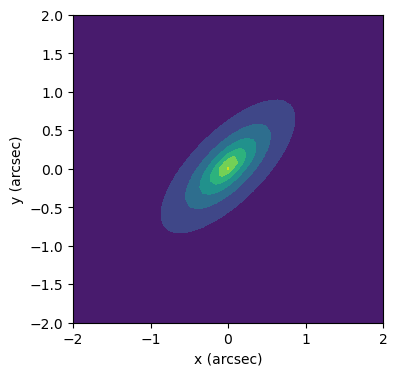

PyObject Text(23.999999999999993, 0.5, 'y (arcsec)')

In [14]:
# Light Parameters
LightParaDict = Dict(:amp=>1., :Rsersic=>1., :q=>0.6,:varphi=>pi/4,
                :xcentre=>0.03, :ycentre=>0.0)

SourceLight = ExponentialLight.ExponentialElliptical(xg, yg; LightParaDict...);
fig, ax = PyPlot.subplots(figsize=(4,4))
ax.contourf(x, x, SourceLight)
ax.set_xlabel("x (arcsec)")
ax.set_ylabel("y (arcsec)")

# Sersic sepherical

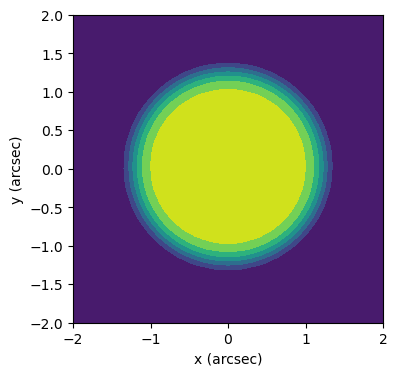

PyObject Text(23.999999999999993, 0.5, 'y (arcsec)')

In [12]:
# Light Parameters
LightParaDict = Dict(:amp=>1., :Rsersic=>0.5, :n=>0.1,
                :xcentre=>0.03, :ycentre=>0.0)

SourceLight = SersicLight.SersicSpheric(xg, yg; LightParaDict...);
fig, ax = PyPlot.subplots(figsize=(4,4))
ax.contourf(x, x, SourceLight)
ax.set_xlabel("x (arcsec)")
ax.set_ylabel("y (arcsec)")

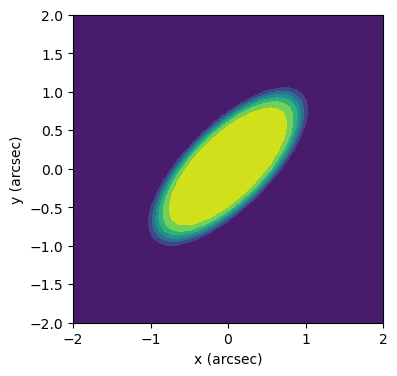

PyObject Text(23.999999999999993, 0.5, 'y (arcsec)')

In [11]:
# Light Parameters
LightParaDict = Dict(:amp=>1., :Rsersic=>0.5, :n=>0.1,:q=>0.6,:varphi=>pi/4,
                :xcentre=>0.03, :ycentre=>0.0)

SourceLight = SersicLight.SersicElliptical(xg, yg; LightParaDict...);
fig, ax = PyPlot.subplots(figsize=(4,4))
ax.contourf(x, x, SourceLight)
ax.set_xlabel("x (arcsec)")
ax.set_ylabel("y (arcsec)")

# Point Source

In [18]:
using Meshes

In [19]:
x = 0.0:0.2:1.0
y = [0.0, 0.1, 0.3, 0.7, 0.9, 1.0]
grid = RectilinearGrid(x, y)

5×5 RectilinearGrid
  36 vertices
  ├─ Point(x: 0.0 m, y: 0.0 m)
  ├─ Point(x: 0.2 m, y: 0.0 m)
  ├─ Point(x: 0.4 m, y: 0.0 m)
  ├─ Point(x: 0.6 m, y: 0.0 m)
  ├─ Point(x: 0.8 m, y: 0.0 m)
  ⋮
  ├─ Point(x: 0.2 m, y: 1.0 m)
  ├─ Point(x: 0.4 m, y: 1.0 m)
  ├─ Point(x: 0.6 m, y: 1.0 m)
  ├─ Point(x: 0.8 m, y: 1.0 m)
  └─ Point(x: 1.0 m, y: 1.0 m)
  25 elements
  ├─ Quadrangle(1, 2, 8, 7)
  ├─ Quadrangle(2, 3, 9, 8)
  ├─ Quadrangle(3, 4, 10, 9)
  ├─ Quadrangle(4, 5, 11, 10)
  ├─ Quadrangle(5, 6, 12, 11)
  ⋮
  ├─ Quadrangle(25, 26, 32, 31)
  ├─ Quadrangle(26, 27, 33, 32)
  ├─ Quadrangle(27, 28, 34, 33)
  ├─ Quadrangle(28, 29, 35, 34)
  └─ Quadrangle(29, 30, 36, 35)

In [26]:
typeof(grid) <: AbstractArray

false